In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

df = pd.read_csv(r'E:\Infosys\data\before\city_day.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 rows:\n", df.head())

Dataset Shape: (29531, 16)

Columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data Types:
 City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

Missing Values:
 City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

First 5 rows:
         City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0 

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

def handle_missing_values(df):
    numerical_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 
                     'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']
    
    for col in numerical_cols:
        if col in df.columns:
            df[col] = df.groupby('City')[col].transform(lambda x: x.fillna(x.median()))
    
    for col in numerical_cols:
        if col in df.columns and df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    if 'AQI_Bucket' in df.columns:
        df['AQI_Bucket'] = df['AQI_Bucket'].fillna('Moderate')
    
    return df

df_clean = handle_missing_values(df.copy())

print("Missing values after cleaning:\n", df_clean.isnull().sum())

Missing values after cleaning:
 0


Summary Statistics:
                                Date         PM2.5          PM10  \
count                          29531  29531.000000  29531.000000   
mean   2018-05-14 05:40:15.807118080     64.495018    111.529814   
min              2015-01-01 00:00:00      0.040000      0.010000   
25%              2017-04-16 00:00:00     28.080000     63.775000   
50%              2018-08-05 00:00:00     48.170000    100.685000   
75%              2019-09-03 00:00:00     76.345000    125.615000   
max              2020-07-01 00:00:00    949.990000   1000.000000   
std                              NaN     60.418818     75.030435   

                 NO           NO2           NOx           NH3            CO  \
count  29531.000000  29531.000000  29531.000000  29531.000000  29531.000000   
mean      17.586426     28.038496     31.738348     21.785599      2.469716   
min        0.020000      0.010000      0.000000      0.010000      0.000000   
25%        6.100000     12.080000     14.495000    

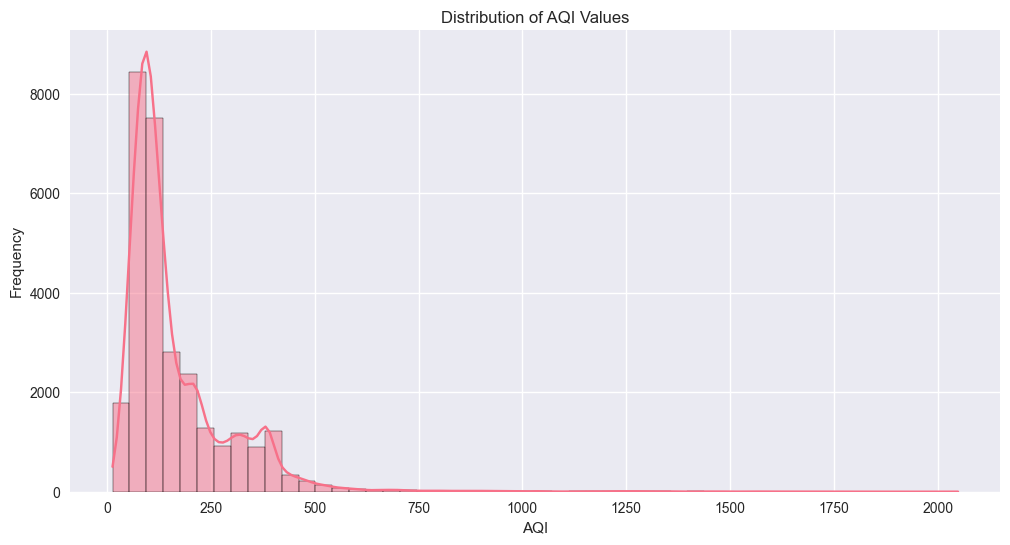

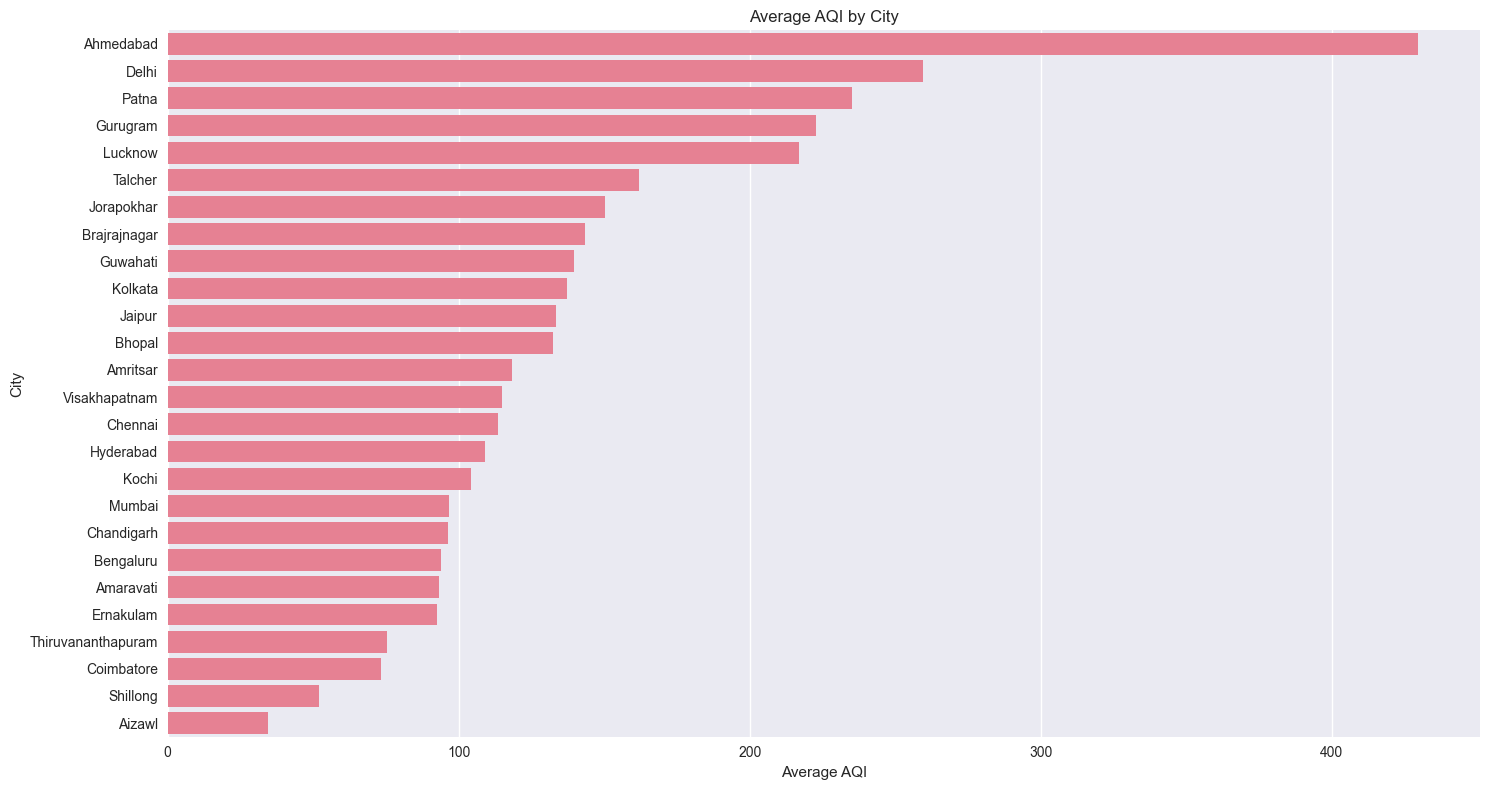

In [3]:
print("Summary Statistics:")
print(df_clean.describe())

plt.figure(figsize=(12, 6))
sns.histplot(df_clean['AQI'].dropna(), kde=True, bins=50)
plt.title('Distribution of AQI Values')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(15, 8))
city_aqi = df_clean.groupby('City')['AQI'].mean().sort_values(ascending=False)
sns.barplot(x=city_aqi.values, y=city_aqi.index)
plt.title('Average AQI by City')
plt.xlabel('Average AQI')
plt.ylabel('City')
plt.tight_layout()
plt.show()

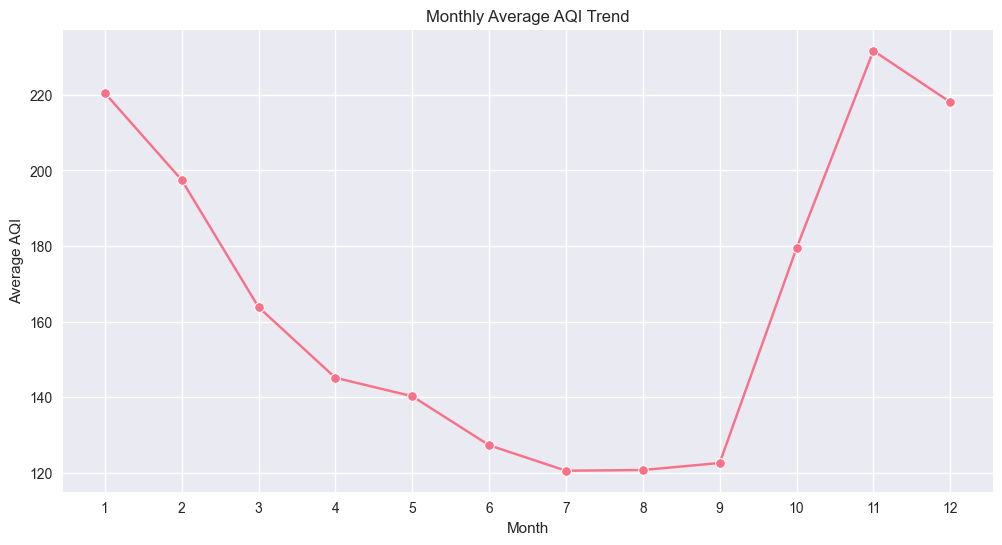

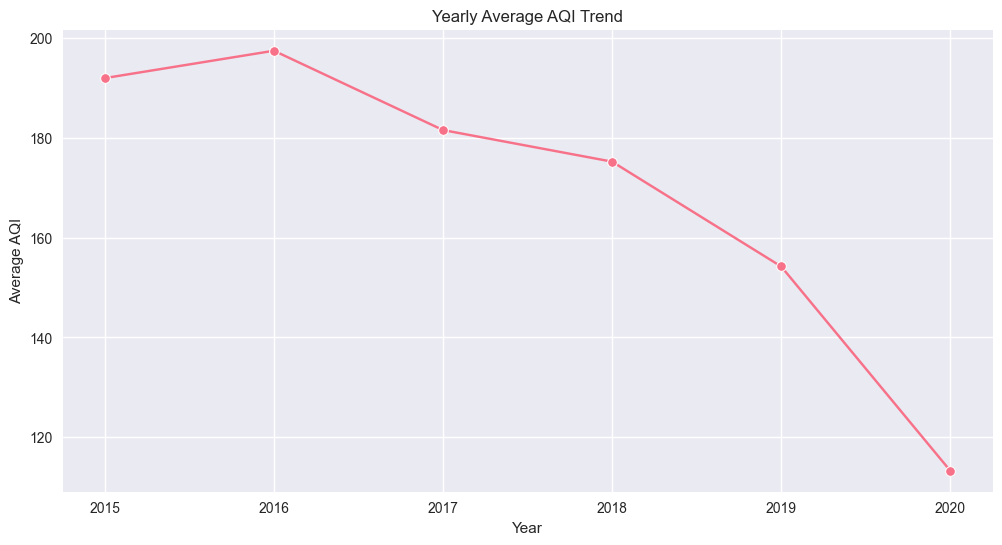

In [4]:
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek

plt.figure(figsize=(12, 6))
monthly_trend = df_clean.groupby('Month')['AQI'].mean()
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='o')
plt.title('Monthly Average AQI Trend')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
yearly_trend = df_clean.groupby('Year')['AQI'].mean()
sns.lineplot(x=yearly_trend.index, y=yearly_trend.values, marker='o')
plt.title('Yearly Average AQI Trend')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.grid(True)
plt.show()

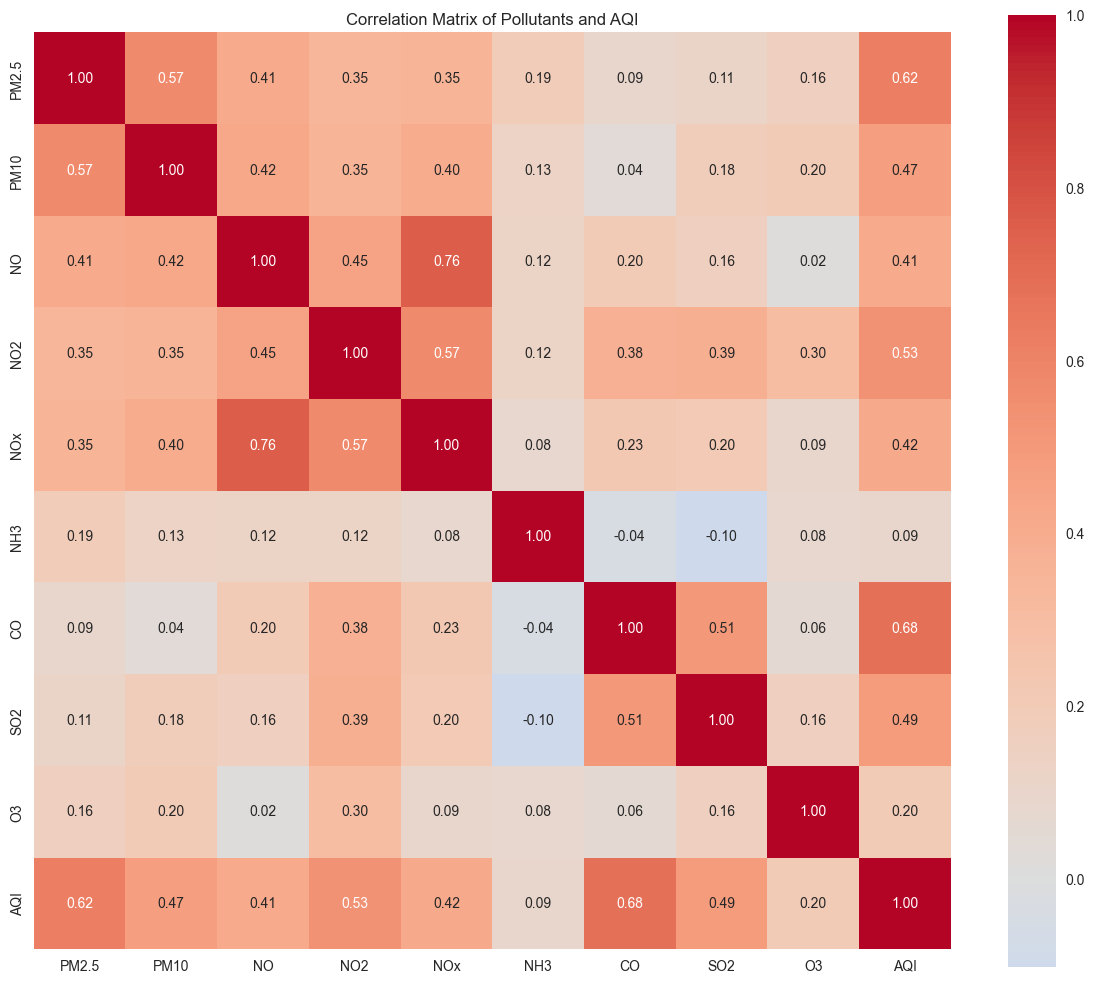

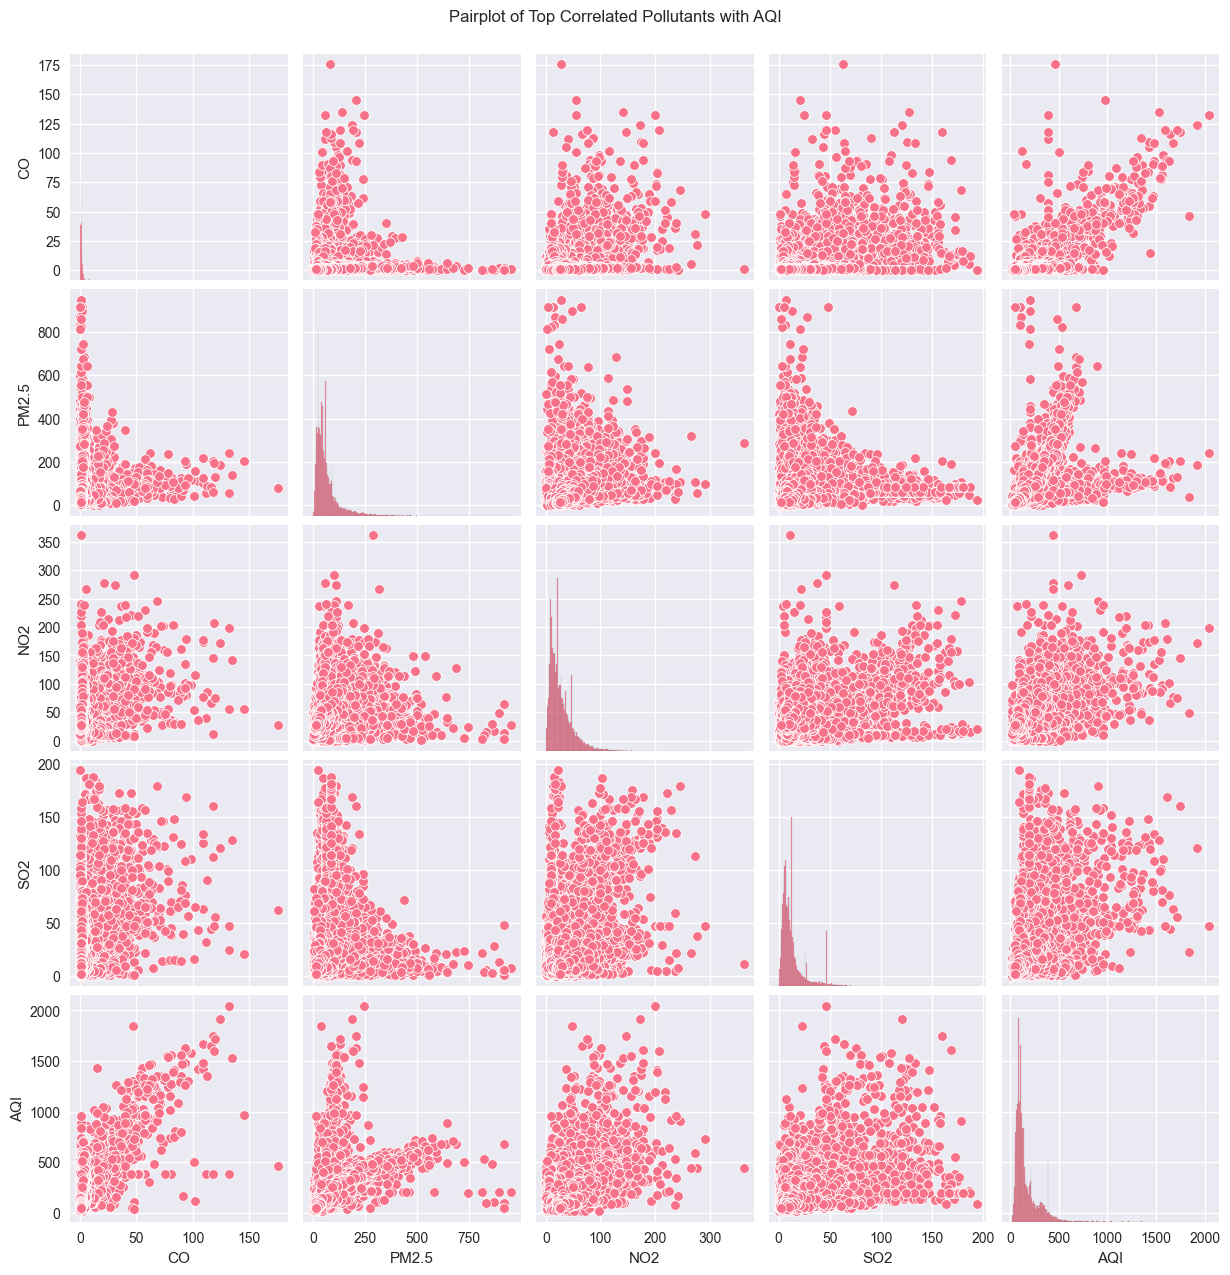

In [5]:
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI']
correlation_matrix = df_clean[pollutants].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Correlation Matrix of Pollutants and AQI')
plt.tight_layout()
plt.show()

top_correlated = correlation_matrix['AQI'].abs().sort_values(ascending=False).index[1:5]
sns.pairplot(df_clean[list(top_correlated) + ['AQI']].dropna())
plt.suptitle('Pairplot of Top Correlated Pollutants with AQI', y=1.02)
plt.show()

City-wise Air Quality Statistics:
                       AQI                  PM2.5    PM10    NO2
                      mean median     std    mean    mean   mean
City                                                            
Ahmedabad           429.40  384.5  255.99   64.89  109.30  55.44
Aizawl               34.56   23.0   19.85   17.01   23.31   0.39
Amaravati            93.30   78.0   53.01   37.17   75.70  21.78
Amritsar            118.45  101.0   74.08   54.28  114.32  18.35
Bengaluru            93.91   86.0   38.96   35.46   82.19  27.99
Bhopal              132.34  120.0   54.98   49.90  119.36  31.38
Brajrajnagar        143.50  122.0   62.52   63.38  123.33  16.41
Chandigarh           96.26   82.0   56.74   40.74   85.66  11.61
Chennai             113.60  100.0   50.45   50.14   52.14  16.83
Coimbatore           73.24   75.0   17.06   29.14   37.95  28.65
Delhi               259.48  257.0  119.24  117.17  232.19  50.78
Ernakulam            92.45   94.0   18.84   24.82   48.2

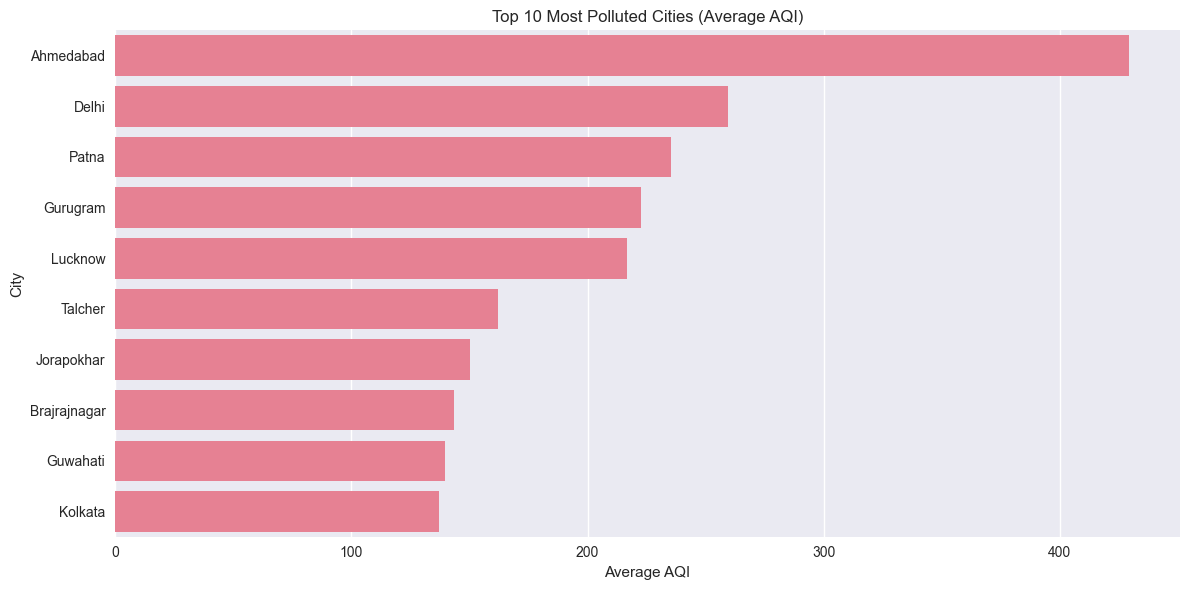

In [6]:
city_stats = df_clean.groupby('City').agg({
    'AQI': ['mean', 'median', 'std'],
    'PM2.5': 'mean',
    'PM10': 'mean',
    'NO2': 'mean'
}).round(2)

print("City-wise Air Quality Statistics:")
print(city_stats)

top_polluted = city_stats[('AQI', 'mean')].sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_polluted.values, y=top_polluted.index)
plt.title('Top 10 Most Polluted Cities (Average AQI)')
plt.xlabel('Average AQI')
plt.tight_layout()
plt.show()

In [7]:
def create_features(df):
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['Quarter'] = df['Date'].dt.quarter
    df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
    
    df['Season'] = df['Month'].apply(lambda x: 
        'Winter' if x in [12, 1, 2] else
        'Spring' if x in [3, 4, 5] else
        'Summer' if x in [6, 7, 8] else 'Autumn')
    
    if all(col in df.columns for col in ['PM2.5', 'PM10']):
        df['PM2.5_PM10_Ratio'] = df['PM2.5'] / df['PM10']
    
    if all(col in df.columns for col in ['NO2', 'NO']):
        df['NO2_NO_Ratio'] = df['NO2'] / (df['NO'] + 1)  
    
    pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
    for poll in pollutants:
        if poll in df.columns:
            df[f'{poll}_Level'] = pd.qcut(df[poll], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
    
    df = df.sort_values(['City', 'Date'])
    for lag in [1, 7, 30]:  
        for poll in ['AQI', 'PM2.5', 'PM10']:
            if poll in df.columns:
                df[f'{poll}_Lag_{lag}'] = df.groupby('City')[poll].shift(lag)
    
    for window in [7, 30]:  
        for poll in ['AQI', 'PM2.5']:
            if poll in df.columns:
                df[f'{poll}_Rolling_Mean_{window}'] = df.groupby('City')[poll].transform(
                    lambda x: x.rolling(window=window, min_periods=1).mean())
                df[f'{poll}_Rolling_Std_{window}'] = df.groupby('City')[poll].transform(
                    lambda x: x.rolling(window=window, min_periods=1).std())
    
    return df

df_engineered = create_features(df_clean)

print("New features created:")
new_features = [col for col in df_engineered.columns if col not in df_clean.columns]
print(new_features)

New features created:
['AQI_Lag_1', 'PM2.5_Lag_1', 'PM10_Lag_1', 'AQI_Lag_7', 'PM2.5_Lag_7', 'PM10_Lag_7', 'AQI_Lag_30', 'PM2.5_Lag_30', 'PM10_Lag_30', 'AQI_Rolling_Mean_7', 'AQI_Rolling_Std_7', 'PM2.5_Rolling_Mean_7', 'PM2.5_Rolling_Std_7', 'AQI_Rolling_Mean_30', 'AQI_Rolling_Std_30', 'PM2.5_Rolling_Mean_30', 'PM2.5_Rolling_Std_30']


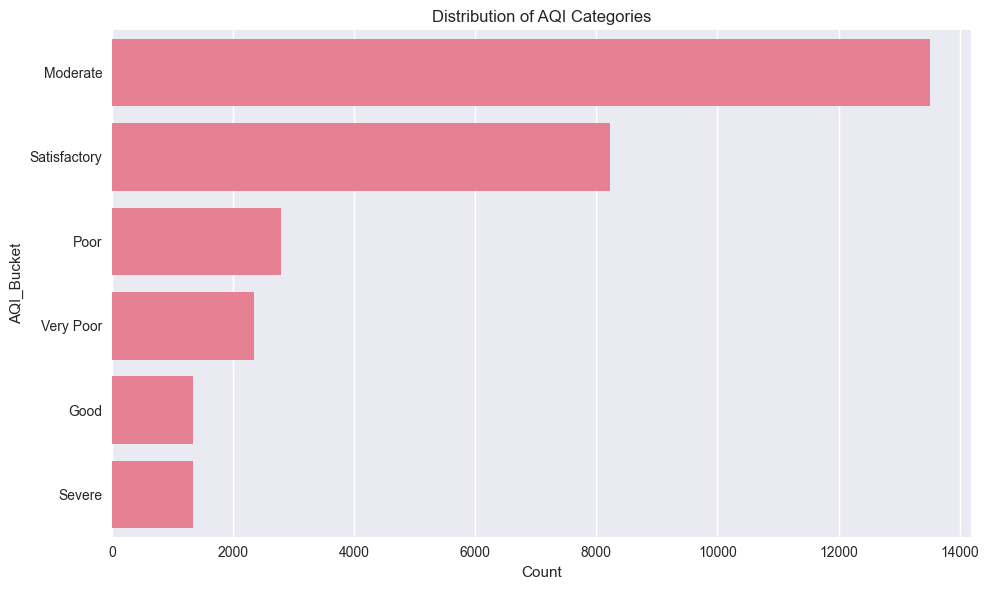

<Figure size 1200x600 with 0 Axes>

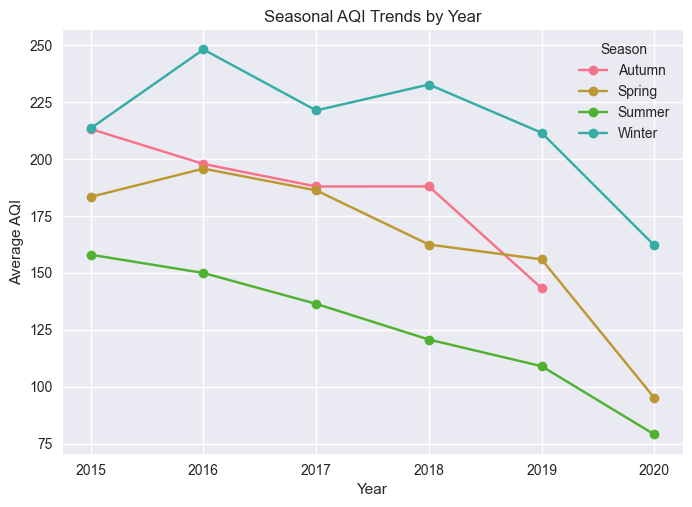

Number of AQI outliers: 1465


In [8]:
if 'AQI_Bucket' in df_engineered.columns:
    plt.figure(figsize=(10, 6))
    aqi_counts = df_engineered['AQI_Bucket'].value_counts()
    sns.barplot(x=aqi_counts.values, y=aqi_counts.index)
    plt.title('Distribution of AQI Categories')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(12, 6))
seasonal_trend = df_engineered.groupby(['Year', 'Season'])['AQI'].mean().unstack()
seasonal_trend.plot(marker='o')
plt.title('Seasonal AQI Trends by Year')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.legend(title='Season')
plt.grid(True)
plt.show()

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

aqi_outliers = detect_outliers_iqr(df_engineered, 'AQI')
print(f"Number of AQI outliers: {len(aqi_outliers)}")

In [9]:
final_features = [
    'City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 
    'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI',
    'Year', 'Month', 'DayOfWeek', 'Season', 'IsWeekend',
    'PM2.5_PM10_Ratio', 'NO2_NO_Ratio',
    'AQI_Lag_1', 'AQI_Lag_7', 'PM2.5_Lag_1',
    'AQI_Rolling_Mean_7', 'PM2.5_Rolling_Mean_7'
]

final_df = df_engineered[[col for col in final_features if col in df_engineered.columns]].copy()

categorical_cols = ['City', 'Season']
final_df = pd.get_dummies(final_df, columns=categorical_cols, drop_first=True)

print("Final dataset shape:", final_df.shape)
print("Final dataset columns:", final_df.columns.tolist())

final_df.to_csv('preprocessed_air_quality_data.csv', index=False)
print("Preprocessed data saved successfully!")

Final dataset shape: (29531, 53)
Final dataset columns: ['Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'Year', 'Month', 'DayOfWeek', 'IsWeekend', 'PM2.5_PM10_Ratio', 'NO2_NO_Ratio', 'AQI_Lag_1', 'AQI_Lag_7', 'PM2.5_Lag_1', 'AQI_Rolling_Mean_7', 'PM2.5_Rolling_Mean_7', 'City_Aizawl', 'City_Amaravati', 'City_Amritsar', 'City_Bengaluru', 'City_Bhopal', 'City_Brajrajnagar', 'City_Chandigarh', 'City_Chennai', 'City_Coimbatore', 'City_Delhi', 'City_Ernakulam', 'City_Gurugram', 'City_Guwahati', 'City_Hyderabad', 'City_Jaipur', 'City_Jorapokhar', 'City_Kochi', 'City_Kolkata', 'City_Lucknow', 'City_Mumbai', 'City_Patna', 'City_Shillong', 'City_Talcher', 'City_Thiruvananthapuram', 'City_Visakhapatnam', 'Season_Spring', 'Season_Summer', 'Season_Winter']
Preprocessed data saved successfully!
